# Weather exploration

A very simple file to access weather data and compare the quality fo them, both from the ERA-5 data, available trhough the Copernicus Climate Data Store and the Taltech campus data.

In [33]:
# !pip install cdsapi

import cdsapi

DOWNLOAD_ERA5_LAND = False
DOWNLOAD_ERA5_CLOUDS = False

In [34]:
# Receiving the data from the Copernicus Climate Data Store
# ERA5-Land: surface meteorology (temperature, wind, irradiance, precipitation)

client = cdsapi.Client()

dataset = "reanalysis-era5-land"

# Download in smaller chunks: one NetCDF per (year, month) to avoid CDS cost-limit errors
if DOWNLOAD_ERA5_LAND:
    for year in range(2022, 2026):
        for month in range(1, 13):
            request = {
                "product_type": "reanalysis",
                "variable": [
                    # Temperature / humidity proxies
                    "2m_temperature",
                    "2m_dewpoint_temperature",
                    # Wind (components at 10 m; speed & direction can be derived)
                    "10m_u_component_of_wind",
                    "10m_v_component_of_wind",
                    # Solar irradiance at the surface
                    "surface_solar_radiation_downwards",
                    # Precipitation / snow
                    "total_precipitation",
                    "snowfall",
                ],
                "year": str(year),
                "month": [f"{month:02d}"],
                "day": [f"{d:02d}" for d in range(1, 32)],
                "time": [f"{h:02d}:00" for h in range(24)],
                "format": "netcdf",
                # Small box around TalTech campus: [N, W, S, E]
                "area": [
                    59.40,   # North latitude
                    24.66,   # West longitude
                    59.38,   # South latitude
                    24.68,   # East longitude
                ]
            }

            target = f"taltech_era5land_surface_{year}_{month:02d}.nc"
            print(f"Requesting ERA5-Land {year}-{month:02d} -> {target}")
            client.retrieve(dataset, request, target)
else:
    print("ERA5-Land data already downloaded")


ERA5-Land data already downloaded


In [35]:
# ERA5 single levels: cloud cover fields for the same period and location

# Note: Cloud cover is not available from ERA5-Land; we use ERA5 single levels instead.

dataset_cloud = "reanalysis-era5-single-levels"

# Download cloud-cover fields in smaller chunks: one NetCDF per (year, month)
if DOWNLOAD_ERA5_CLOUDS:
    for year in range(2022, 2026):
        for month in range(1, 13):
            request_cloud = {
                "product_type": "reanalysis",
                "variable": [
                    "total_cloud_cover",
                    "low_cloud_cover",
                    "medium_cloud_cover",
                    "high_cloud_cover",
                ],
                "year": str(year),
                "month": [f"{month:02d}"],
                "day": [f"{d:02d}" for d in range(1, 32)],
                "time": [f"{h:02d}:00" for h in range(24)],
                "area": [
                    59.40,   # North latitude
                    24.66,   # West longitude
                    59.38,   # South latitude
                    24.68,   # East longitude
                ],
                "format": "netcdf",
            }

            target_cloud = f"taltech_era5_clouds_{year}_{month:02d}.nc"
            print(f"Requesting ERA5 clouds {year}-{month:02d} -> {target_cloud}")
            client.retrieve(dataset_cloud, request_cloud, target_cloud)
else:
    print("ERA5 clouds data already downloaded")


ERA5 clouds data already downloaded


---
## Load Copernicus data

Read **one** `.nc` file, inspect what it contains, then build from that. ([Reading NetCDF in Python](https://stackoverflow.com/questions/36360469/read-nc-netcdf-files-using-python))

In [36]:
from pathlib import Path
import xarray as xr

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "copernicus-era5-taltech"
one_nc = DATA_DIR / "taltech_era5_clouds_2022_01.nc"
ds = xr.open_dataset(one_nc)
print(ds)

<xarray.Dataset> Size: 30kB
Dimensions:     (valid_time: 744, latitude: 1, longitude: 1)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 6kB 2022-01-01 ... 2022-01-31T23:...
  * latitude    (latitude) float64 8B 59.38
  * longitude   (longitude) float64 8B 24.66
    expver      (valid_time) <U4 12kB ...
Data variables:
    tcc         (valid_time, latitude, longitude) float32 3kB ...
    lcc         (valid_time, latitude, longitude) float32 3kB ...
    mcc         (valid_time, latitude, longitude) float32 3kB ...
    hcc         (valid_time, latitude, longitude) float32 3kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-06T21:34 GRIB to CDM+CF via cfgrib-0.9.1...


In [37]:
# What's in it
print("Dimensions:", dict(ds.sizes))
print("Data variables:", list(ds.data_vars))
print("Coords:", list(ds.coords))
v = list(ds.data_vars)[0]
print(f"{v} shape: {ds[v].dims} = {ds[v].shape}")

Dimensions: {'valid_time': 744, 'latitude': 1, 'longitude': 1}
Data variables: ['tcc', 'lcc', 'mcc', 'hcc']
Coords: ['number', 'valid_time', 'latitude', 'longitude', 'expver']
tcc shape: ('valid_time', 'latitude', 'longitude') = (744, 1, 1)


In [38]:
# From this one file: time index + one variable at the point
import pandas as pd
ds_point = ds.isel(latitude=0, longitude=0)
t = pd.to_datetime(ds_point["valid_time"].values)
df_one = pd.DataFrame({"tcc": ds_point["tcc"].values}, index=t)
df_one.index.name = "time"
df_one.head()

,tcc
time,
2022-01-01 00:00:00,1.000000
2022-01-01 01:00:00,1.000000
2022-01-01 02:00:00,1.000000
2022-01-01 03:00:00,0.999923
2022-01-01 04:00:00,0.988140


The surface files were downloaded as GRIB inside ZIP. Convert them to real NetCDF once so `xr.open_dataset()` works the same way as for clouds.

In [39]:
# Fix surface files that have a bad 'step' coord (from earlier GRIB conversion).
# Opens each file, drops 'step' if present, re-saves. Run once, then set to False.
FIX_SURFACE = True

if FIX_SURFACE:
    for f in sorted(DATA_DIR.glob("taltech_era5land_surface_*.nc")):
        d = xr.open_dataset(f, decode_timedelta=False)
        if "step" not in d.coords:
            d.close()
            continue
        d = d.load()
        d = d.drop_vars(["step", "number", "surface", "time"], errors="ignore")
        for v in list(d.coords) + list(d.data_vars):
            d[v].attrs.pop("dtype", None)
            d[v].encoding.clear()
        d.attrs = {k: v for k, v in d.attrs.items() if k != "dtype"}
        d.to_netcdf(f)
        print(f"Fixed {f.name}")
        d.close()
    print("Done — set FIX_SURFACE = False")

Done — set FIX_SURFACE = False


In [40]:
import numpy as np
surface_files = sorted(DATA_DIR.glob("taltech_era5land_surface_*.nc"))
parts = []
for f in surface_files:
    d = xr.open_dataset(f).isel(latitude=0, longitude=0)
    t = pd.to_datetime(d["valid_time"].values.ravel())
    parts.append(pd.DataFrame({
        "t2m": d["t2m"].values.ravel(), "d2m": d["d2m"].values.ravel(),
        "u10": d["u10"].values.ravel(), "v10": d["v10"].values.ravel(),
        "ssrd": d["ssrd"].values.ravel(), "tp": d["tp"].values.ravel(), "sf": d["sf"].values.ravel(),
    }, index=t))
flat = pd.concat(parts).sort_index()
flat.index.name = "datetime"

# De-accumulate ssrd: ERA5-Land ssrd is accumulated from 00:00 UTC each day.
# Raw values are running totals (monotonically increasing within a day).
# Step 1 (01:00 UTC): accumulation for hour 00-01 (value = hourly amount)
# Step N (N:00 UTC): accumulation for hours 00-N  (value = total since 00:00)
# Step 24 (00:00 UTC next day): full-day total
#
# To get hourly: diff consecutive values.
# At genuine forecast resets (01:00 of each new day, where value drops from
# previous day's large accumulated total to a small step-1 value): use raw value.
# Floating-point noise (tiny drops like -1 J/m²): clamp to 0.
ssrd_raw = flat["ssrd"].copy()
ssrd_diff = ssrd_raw.diff()

# Genuine reset = large negative jump (new daily forecast cycle).
# A threshold of -3600 J/m² (= 1 W/m² equivalent) separates real resets
# from floating-point noise.
genuine_reset = ssrd_diff < -3600
ssrd_hourly = ssrd_diff.copy()
ssrd_hourly[genuine_reset] = ssrd_raw[genuine_reset]  # step-1 value IS hourly

# First entry: NaN diff — cannot determine hourly value, leave as NaN
# (do NOT substitute the raw accumulated value, which is a multi-hour total)

# Clamp tiny floating-point negatives (e.g., -1 J/m²) to 0
ssrd_hourly = ssrd_hourly.clip(lower=0)

era5 = pd.DataFrame(index=flat.index, data={
    "temp_c": flat["t2m"] - 273.15,
    "wind_speed_ms": np.sqrt(flat["u10"]**2 + flat["v10"]**2),
    "ssrd_W_per_m2": ssrd_hourly / 3600,  # J/m² per hour -> W/m²
})
print(len(era5), "hours")
print(f"ssrd range: {era5['ssrd_W_per_m2'].min():.1f} - {era5['ssrd_W_per_m2'].max():.1f} W/m2")
era5.head()

36216 hours
ssrd range: 0.0 - 812.8 W/m2


,temp_c,wind_speed_ms,ssrd_W_per_m2
datetime,,,
2021-12-31 01:00:00,NaN,NaN,NaN
2021-12-31 02:00:00,NaN,NaN,NaN
2021-12-31 03:00:00,NaN,NaN,NaN
2021-12-31 04:00:00,NaN,NaN,NaN
2021-12-31 05:00:00,NaN,NaN,NaN


---
## Plot Copernicus ERA5-Land alone

Time series of 2 m temperature, 10 m wind speed, and surface solar radiation (hourly mean W/m²) at the TalTech grid point.

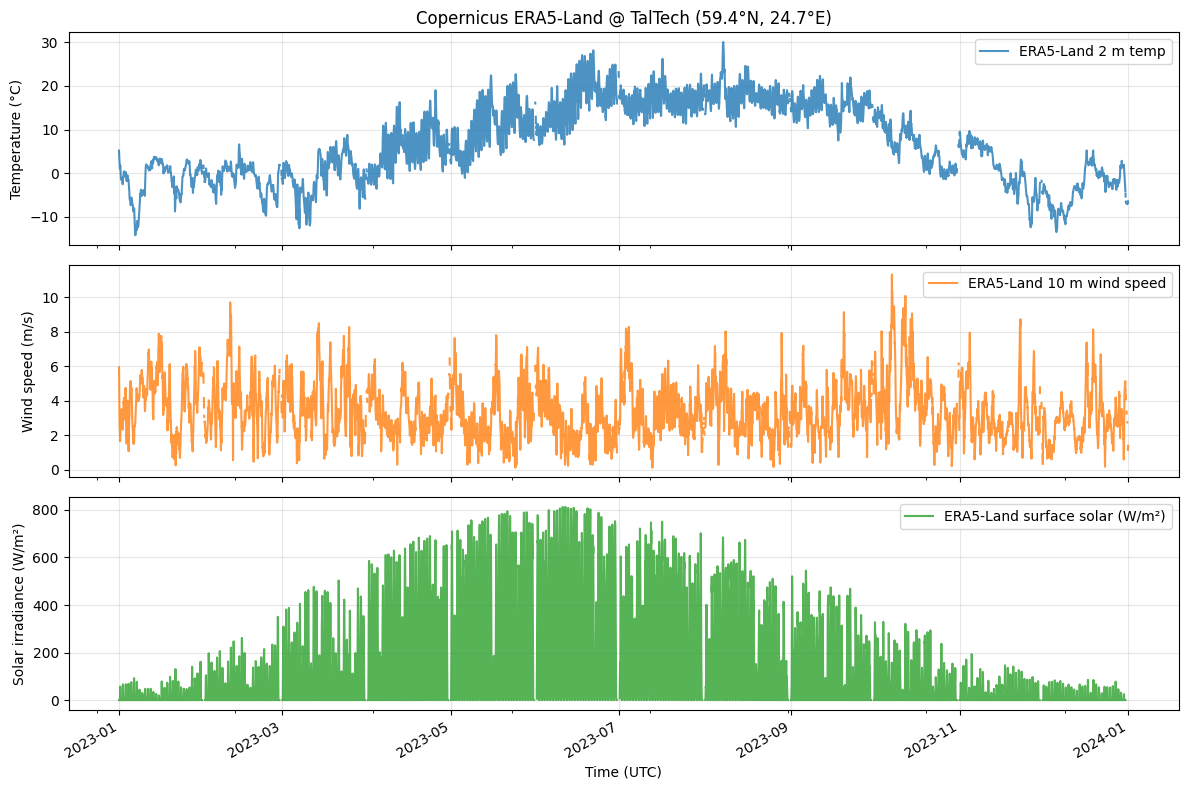

In [41]:
import matplotlib.pyplot as plt

# Plot a subset (e.g. one year) so lines are visible
era5_plot = era5.loc["2023-01-01":"2023-12-31"] if len(era5) > 8760 else era5

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
era5_plot["temp_c"].plot(ax=axes[0], color="C0", alpha=0.8, label="ERA5-Land 2 m temp")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend(loc="upper right")
axes[0].set_title("Copernicus ERA5-Land @ TalTech (59.4°N, 24.7°E)")
axes[0].grid(True, alpha=0.3)

era5_plot["wind_speed_ms"].plot(ax=axes[1], color="C1", alpha=0.8, label="ERA5-Land 10 m wind speed")
axes[1].set_ylabel("Wind speed (m/s)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

era5_plot["ssrd_W_per_m2"].plot(ax=axes[2], color="C2", alpha=0.8, label="ERA5-Land surface solar (W/m²)")
axes[2].set_ylabel("Solar irradiance (W/m²)")
axes[2].set_xlabel("Time (UTC)")
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Load keskkonnaportaal (Tallinn-Harku) weather

Same cleaned source as in `smertinas-es-exploration.ipynb`: hourly weather from the Estonian environment portal, station Tallinn-Harku (~5 km from campus). We use it as the **reference** (local, accurate) to check that Copernicus is good enough for ES-style analysis.

In [42]:
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from utils.building_data_loader import load_weather_dataframe, WEATHER_COLUMN_RENAME

# Load and rename to same column names as in building_df (air_temp_c, wind_speed_ms, sunshine_duration_min)
weather_path = PROJECT_ROOT / "data" / "keskkonnaportaal" / "tallinn-harku_f_kliima_tund.csv"
harku = load_weather_dataframe(weather_path)
harku = harku.rename(columns={"Time": "datetime", **WEATHER_COLUMN_RENAME})
harku["datetime"] = pd.to_datetime(harku["datetime"])
# Keep only columns we need for comparison
harku = harku[["datetime", "air_temp_c", "wind_speed_ms", "sunshine_duration_min"]].dropna(subset=["air_temp_c", "wind_speed_ms"])
harku = harku.set_index("datetime").sort_index()
print("Keskkonnaportaal (Tallinn-Harku) hourly — shape:", harku.shape)
harku.head(10)

Keskkonnaportaal (Tallinn-Harku) hourly — shape: (34663, 3)


,air_temp_c,wind_speed_ms,sunshine_duration_min
datetime,,,
2022-01-01 00:00:00,0.0,1.4,0.0
2022-01-01 01:00:00,-0.1,1.0,0.0
2022-01-01 02:00:00,-0.1,1.5,0.0
2022-01-01 03:00:00,-0.3,1.9,0.0
2022-01-01 04:00:00,-0.4,1.3,0.0
2022-01-01 05:00:00,-0.4,2.9,0.0
2022-01-01 06:00:00,-1.3,4.3,0.0
2022-01-01 07:00:00,-2.8,4.9,0.0
2022-01-01 08:00:00,-2.9,3.4,0.0


---
## Merge and plot: Copernicus vs keskkonnaportaal

Align on datetime (UTC). Overlay temperature, wind speed, and solar (Copernicus: W/m²; Harku: sunshine duration min — different quantity, so we plot both for context).

In [43]:
# Inner join on datetime so we only compare hours present in both
era5_sub = era5[["temp_c", "wind_speed_ms", "ssrd_W_per_m2"]].rename(
    columns={"temp_c": "temp_c_era5", "wind_speed_ms": "wind_ms_era5", "ssrd_W_per_m2": "ssrd_W_per_m2"}
)
harku_sub = harku[["air_temp_c", "wind_speed_ms", "sunshine_duration_min"]].rename(
    columns={"air_temp_c": "temp_c_harku", "wind_speed_ms": "wind_ms_harku"}
)
common = era5_sub.join(harku_sub, how="inner")
print(f"Aligned hourly records: {len(common)}")
common.head()

Aligned hourly records: 35791


,temp_c_era5,wind_ms_era5,ssrd_W_per_m2,temp_c_harku,wind_ms_harku,sunshine_duration_min
datetime,,,,,,
2022-01-01 00:00:00,-1.147308,0.602060,NaN,0.0,1.4,0.0
2022-01-01 01:00:00,-1.441498,1.423145,0.0,-0.1,1.0,0.0
2022-01-01 02:00:00,-1.059174,2.314176,0.0,-0.1,1.5,0.0
2022-01-01 03:00:00,-1.089447,2.695371,0.0,-0.3,1.9,0.0
2022-01-01 04:00:00,-1.583832,3.038821,0.0,-0.4,1.3,0.0


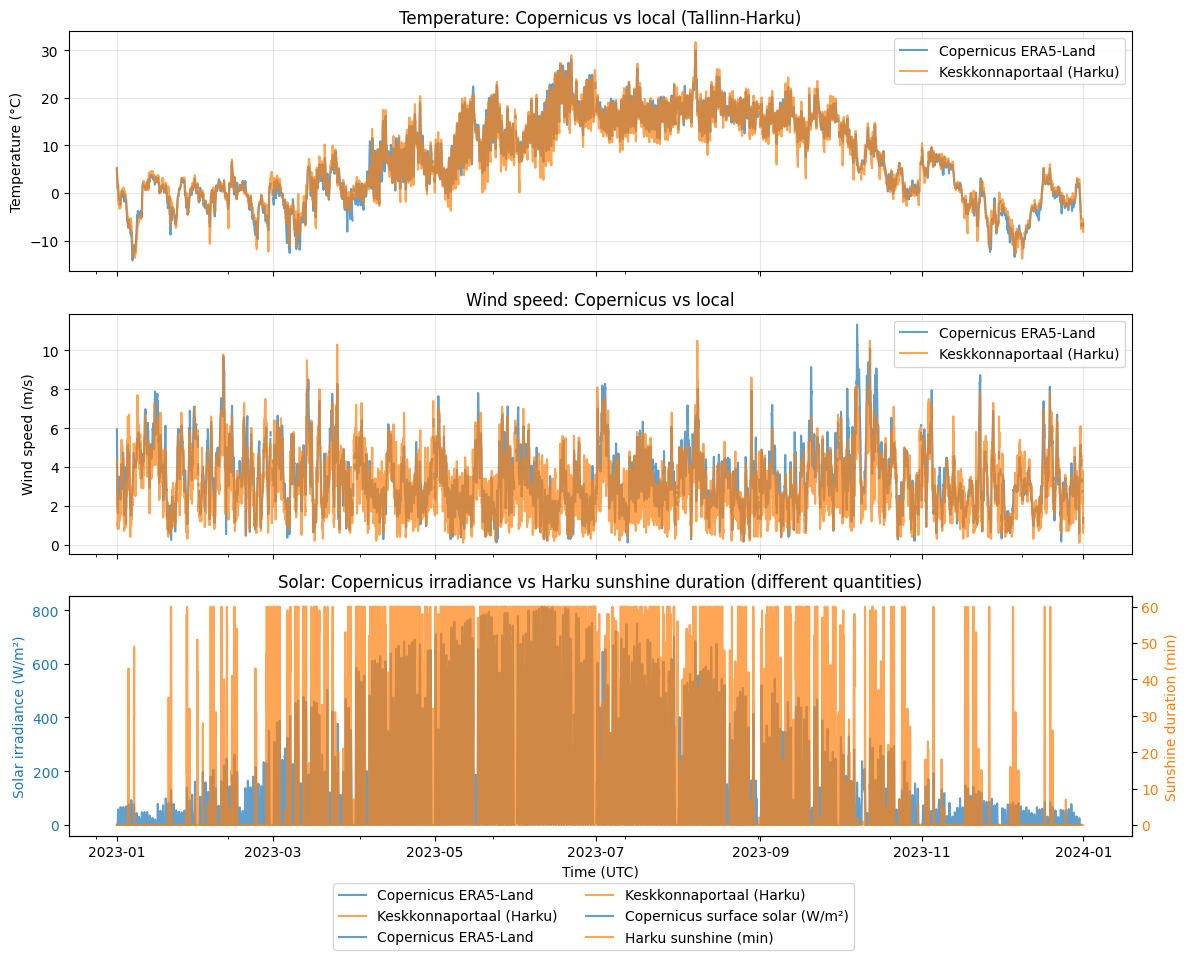

In [44]:
# Overlay: temperature and wind (same units); solar: ERA5 W/m² vs Harku sunshine min (different)
plot_period = common.loc["2023-01-01":"2023-12-31"] if len(common) > 8760 else common

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
plot_period["temp_c_era5"].plot(ax=axes[0], color="C0", alpha=0.7, label="Copernicus ERA5-Land")
plot_period["temp_c_harku"].plot(ax=axes[0], color="C1", alpha=0.7, label="Keskkonnaportaal (Harku)")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend(loc="upper right")
axes[0].set_title("Temperature: Copernicus vs local (Tallinn-Harku)")
axes[0].grid(True, alpha=0.3)

plot_period["wind_ms_era5"].plot(ax=axes[1], color="C0", alpha=0.7, label="Copernicus ERA5-Land")
plot_period["wind_ms_harku"].plot(ax=axes[1], color="C1", alpha=0.7, label="Keskkonnaportaal (Harku)")
axes[1].set_ylabel("Wind speed (m/s)")
axes[1].legend(loc="upper right")
axes[1].set_title("Wind speed: Copernicus vs local")
axes[1].grid(True, alpha=0.3)

ax2 = axes[2]
ax2.plot(plot_period.index, plot_period["ssrd_W_per_m2"], color="C0", alpha=0.7, label="Copernicus surface solar (W/m²)")
ax2.set_ylabel("Solar irradiance (W/m²)", color="C0")
ax2.tick_params(axis="y", labelcolor="C0")
ax2b = ax2.twinx()
ax2b.plot(plot_period.index, plot_period["sunshine_duration_min"], color="C1", alpha=0.7, label="Harku sunshine (min)")
ax2b.set_ylabel("Sunshine duration (min)", color="C1")
ax2b.tick_params(axis="y", labelcolor="C1")
axes[2].set_title("Solar: Copernicus irradiance vs Harku sunshine duration (different quantities)")
axes[2].set_xlabel("Time (UTC)")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=2)
plt.tight_layout()
plt.show()

---
## Build combined weather dataset

Merge Copernicus (COP) and keskkonnaportaal (KKP) with clear column names (prefix + variable + unit) for quick use in other experiments. Save to CSV.

In [45]:
# Rename with clear prefixes
era5_renamed = era5.rename(columns={
    "temp_c": "COP_temp_c",
    "dewpoint_c": "COP_dewpoint_c",
    "wind_speed_ms": "COP_wind_speed_ms",
    "ssrd_W_per_m2": "COP_ssrd_W_per_m2",
    "tp_m": "COP_tp_m",
    "snowfall_m": "COP_snowfall_m",
})
harku_renamed = harku.rename(columns={
    "air_temp_c": "KKP_temp_c",
    "wind_speed_ms": "KKP_wind_speed_ms",
    "sunshine_duration_min": "KKP_sunshine_duration_min",
    "air_pressure_hpa": "KKP_air_pressure_hpa",
    "precipitation_mm": "KKP_precipitation_mm",
    "relative_humidity_pct": "KKP_relative_humidity_pct",
})
# Outer join so we keep all timestamps
combined = era5_renamed.join(harku_renamed, how="outer").sort_index()
combined.index.name = "datetime"
print(f"Combined dataset: {len(combined)} hours, {combined.shape[1]} columns")
combined.head()

Combined dataset: 36216 hours, 6 columns


,COP_temp_c,COP_wind_speed_ms,COP_ssrd_W_per_m2,KKP_temp_c,KKP_wind_speed_ms,KKP_sunshine_duration_min
datetime,,,,,,
2021-12-31 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2021-12-31 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2021-12-31 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2021-12-31 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2021-12-31 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
# Save to data/ for quick loading
out_file = PROJECT_ROOT / "data" / "combined_weather_2022_2025.csv"
combined.to_csv(out_file)
print(f"Saved to {out_file}")

# To load in another notebook:
# combined = pd.read_csv("data/combined_weather_2022_2025.csv", parse_dates=["datetime"], index_col="datetime")

Saved to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/combined_weather_2022_2025.csv


---
## Is Copernicus good enough?

Compare **temperature** and **wind speed** (same units in both sources). Keskkonnaportaal (Harku) is the local reference. We expect small bias and high correlation if ERA5-Land is suitable for ES-style modelling.

In [47]:
# Drop any remaining NaNs for the comparison
cmp = common[["temp_c_era5", "temp_c_harku", "wind_ms_era5", "wind_ms_harku"]].dropna()

# Bias (ERA5 − Harku): positive = ERA5 warmer / windier
temp_bias = (cmp["temp_c_era5"] - cmp["temp_c_harku"]).mean()
wind_bias = (cmp["wind_ms_era5"] - cmp["wind_ms_harku"]).mean()
temp_rmse = np.sqrt(((cmp["temp_c_era5"] - cmp["temp_c_harku"]) ** 2).mean())
wind_rmse = np.sqrt(((cmp["wind_ms_era5"] - cmp["wind_ms_harku"]) ** 2).mean())
temp_r = cmp["temp_c_era5"].corr(cmp["temp_c_harku"])
wind_r = cmp["wind_ms_era5"].corr(cmp["wind_ms_harku"])

print("Comparison (Copernicus ERA5-Land vs Keskkonnaportaal Tallinn-Harku)")
print("=" * 55)
print(f"  Temperature:  bias = {temp_bias:+.2f} °C   RMSE = {temp_rmse:.2f} °C   r = {temp_r:.3f}")
print(f"  Wind speed:  bias = {wind_bias:+.2f} m/s  RMSE = {wind_rmse:.2f} m/s  r = {wind_r:.3f}")
print()
print("Conclusion: Copernicus is 'good enough' for ES-style analysis if bias and RMSE")
print("are small and correlation is high (r > 0.95 for temp is typical for reanalysis vs station).")

Comparison (Copernicus ERA5-Land vs Keskkonnaportaal Tallinn-Harku)
  Temperature:  bias = -0.04 °C   RMSE = 1.26 °C   r = 0.989
  Wind speed:  bias = +0.46 m/s  RMSE = 1.02 m/s  r = 0.824

Conclusion: Copernicus is 'good enough' for ES-style analysis if bias and RMSE
are small and correlation is high (r > 0.95 for temp is typical for reanalysis vs station).


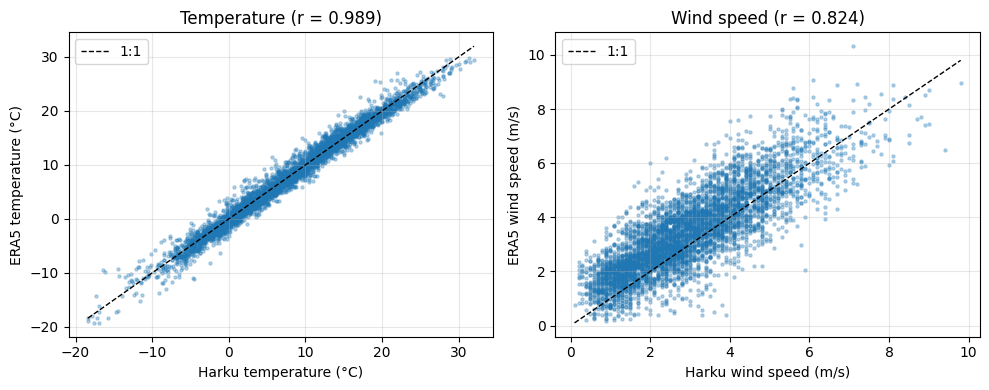

In [48]:
# Scatter: ERA5 vs Harku (perfect agreement = diagonal line)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
# Subsample for scatter if too many points
n_plot = min(5000, len(cmp))
c = cmp.sample(n=n_plot, random_state=42) if len(cmp) > n_plot else cmp
ax1.scatter(c["temp_c_harku"], c["temp_c_era5"], alpha=0.3, s=5)
ax1.plot([c["temp_c_harku"].min(), c["temp_c_harku"].max()], [c["temp_c_harku"].min(), c["temp_c_harku"].max()], "k--", lw=1, label="1:1")
ax1.set_xlabel("Harku temperature (°C)")
ax1.set_ylabel("ERA5 temperature (°C)")
ax1.set_title(f"Temperature (r = {temp_r:.3f})")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(c["wind_ms_harku"], c["wind_ms_era5"], alpha=0.3, s=5)
ax2.plot([c["wind_ms_harku"].min(), c["wind_ms_harku"].max()], [c["wind_ms_harku"].min(), c["wind_ms_harku"].max()], "k--", lw=1, label="1:1")
ax2.set_xlabel("Harku wind speed (m/s)")
ax2.set_ylabel("ERA5 wind speed (m/s)")
ax2.set_title(f"Wind speed (r = {wind_r:.3f})")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()